In [2]:
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
params = np.load("/Users/hgoldwyn/Research/projects/SR_CNN/paper_repo/sr_ordered_train0p75/stage_2/output/parCov_fitting_fourier_allImages_mseStart_globalPrior_anal_empPriorStdOn4p5_param_fits.npy")

In [4]:
params.shape

(642, 1089)

In [5]:
train_mse_mean_fields = np.load("../stage_1/output_data/mse_5l_i123_c32s_padR_schLrG0p95_reg0_trainPredFields.npy")


In [6]:
test_mse_mean_fields = np.load("../stage_1/output_data/mse_5l_i123_c32s_padR_schLrG0p95_reg0_testPredFields.npy")

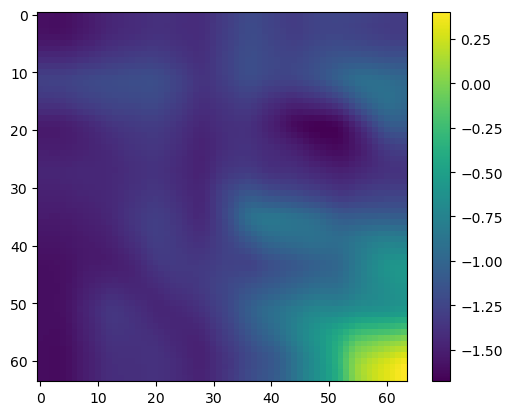

In [7]:
plt.imshow(train_mse_mean_fields[0])
plt.colorbar()

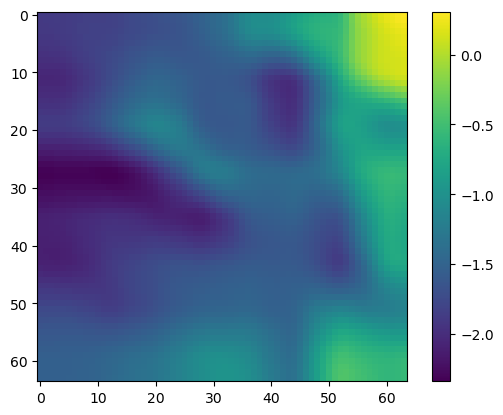

In [8]:
plt.imshow(train_mse_mean_fields[1])
plt.colorbar()

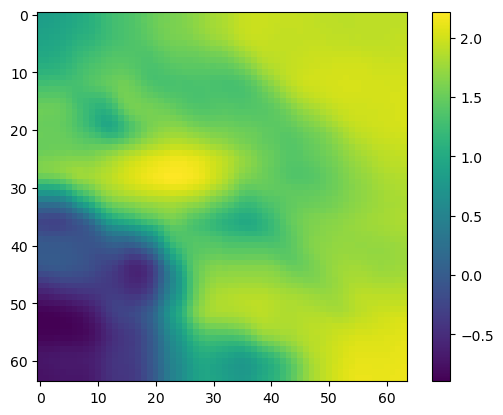

In [9]:
plt.imshow(test_mse_mean_fields[0])
plt.colorbar()

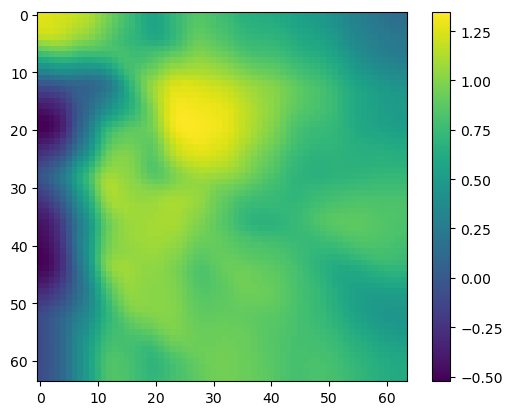

In [10]:
plt.imshow(train_mse_mean_fields[10])
plt.colorbar()

In [11]:
train_mse_mean_fields.shape

(642, 64, 64)

In [12]:
## Test fit results

In [13]:
# ------------------------------
# Load inputs
# ------------------------------
# error_fields = np.load("../stage_1/mse_5l_i123_c32s_padR_schLrG0p95_reg0_TrainErrFields.npy")
s_train = np.load("../stage_2/output/parCov_fitting_fourier_allImages_mseStart_globalPrior_anal_empPriorStdOn4p5_param_fits.npy")
s_test_true = np.load("./stage_2b_kappa4p5_testImage_param_fits.npy")


In [14]:
s_train.shape

(642, 1089)

In [15]:
s_train_grid = s_train.reshape((-1, 33, 33))

In [16]:
s_train_grid[20].shape

(33, 33)

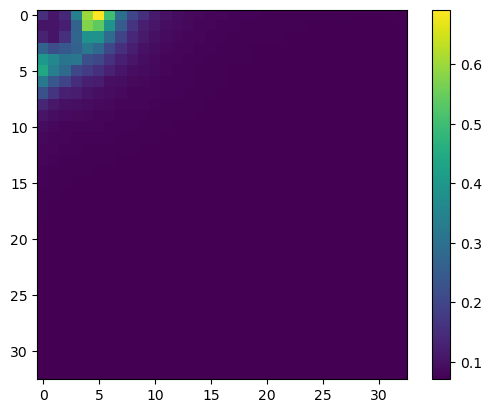

In [19]:
plt.imshow(s_train_grid[2])
plt.colorbar()

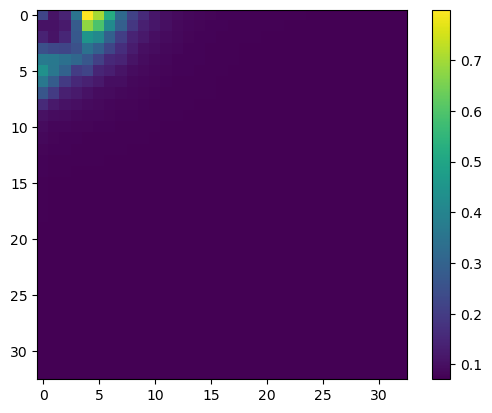

In [20]:
plt.imshow(s_train_grid[1])
plt.colorbar()

In [21]:
s_test_true.shape

(214, 1089)

In [22]:
s_true = s_train              # (642,1089)
s_pred = np.load("train_predicted_s.npy")   # (642,1089)
s_test = np.load("test_predicted_s.npy")   # (214,1089)


In [23]:
s_test.shape

(214, 1089)

In [24]:
# ============================================================
# Build Low-k Mask
# ============================================================
def build_lowk_mask(k_max=10.0):
    """
    Construct a mask for |k| <= k_max over the 33x33 half-plane (kx,ky = 0..32).
    Returns:
        lowk_idx  : array of flattened indices into (33*33=1089)
        mask_flat : boolean mask (1089,)
    """
    N = 64
    kx = np.arange(0, N//2 + 1)  # 0..32
    ky = np.arange(0, N//2 + 1)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    R = np.sqrt(KX**2 + KY**2)

    mask = (R <= k_max)          # (33,33)
    mask_flat = mask.reshape(-1) # (1089,)
    lowk_idx = np.where(mask_flat)[0]

    print(f"Low-k modes: {len(lowk_idx)} of 1089")
    return lowk_idx, mask_flat

In [25]:
lowk_idx, mask_flat = build_lowk_mask(k_max=10)


Low-k modes: 90 of 1089


In [26]:
def to_grid(v):
    return v.reshape(33, 33)


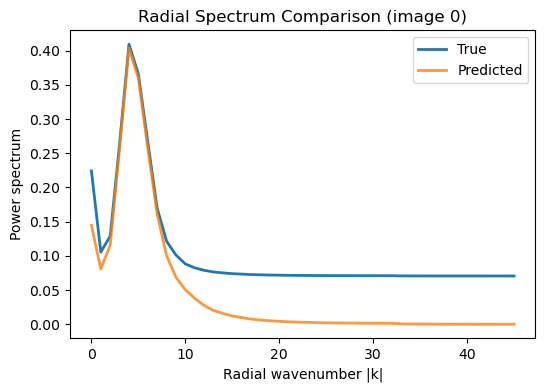

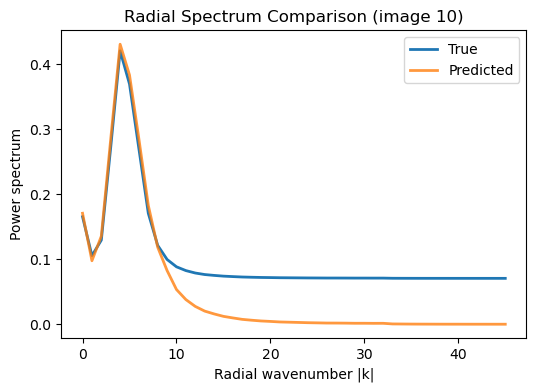

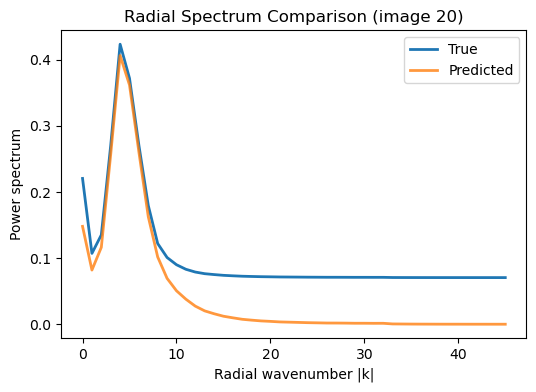

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# compute radial bins
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = (KX**2 + KY**2)**0.5
R_int = R.astype(int)   # integer radii from 0..45 approx

def radial_profile(spec_33x33):
    prof = []
    for r in range(R_int.max()+1):
        prof.append(spec_33x33[R_int == r].mean())
    return np.array(prof)

# visualize for a few images
for idx in [0, 10, 20]:
    plt.figure(figsize=(6,4))
    true_grid = to_grid(s_true[idx])
    pred_grid = to_grid(s_pred[idx])
    
    rt = radial_profile(true_grid)
    rp = radial_profile(pred_grid)
    
    plt.plot(rt, label="True", lw=2)
    plt.plot(rp, label="Predicted", lw=2, alpha=0.8)
    # plt.yscale("log")
    plt.xlabel("Radial wavenumber |k|")
    plt.ylabel("Power spectrum")
    plt.title(f"Radial Spectrum Comparison (image {idx})")
    plt.legend()
    plt.show()


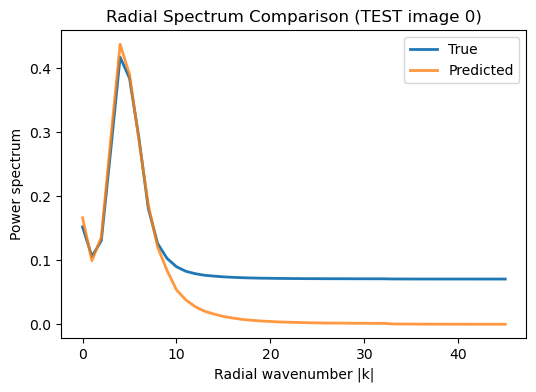

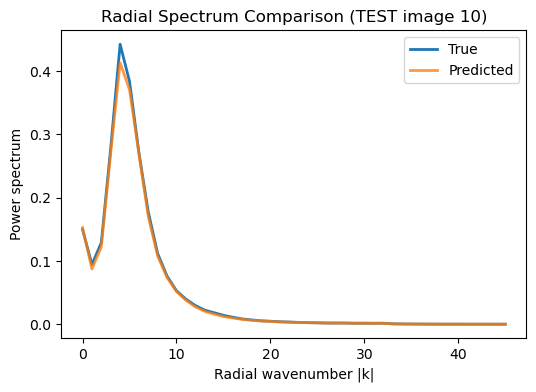

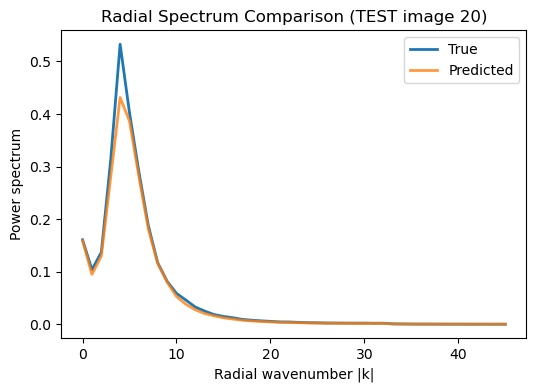

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# visualize for a few images
for idx in [0, 10, 20]:
    plt.figure(figsize=(6,4))
    true_grid = to_grid(s_test_true[idx])
    pred_grid = to_grid(s_test[idx])
    
    rt = radial_profile(true_grid)
    rp = radial_profile(pred_grid)
    
    plt.plot(rt, label="True", lw=2)
    plt.plot(rp, label="Predicted", lw=2, alpha=0.8)
    # plt.yscale("log")
    plt.xlabel("Radial wavenumber |k|")
    plt.ylabel("Power spectrum")
    plt.title(f"Radial Spectrum Comparison (TEST image {idx})")
    plt.legend()
    plt.show()


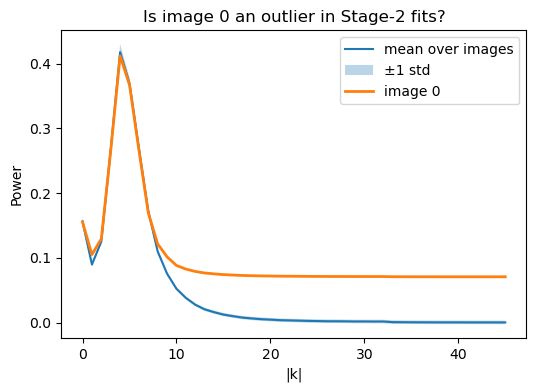

In [25]:
def radial_profile(spec_33x33, R_int):
    vals = []
    for r in range(R_int.max()+1):
        vals.append(spec_33x33[R_int == r].mean())
    return np.array(vals)

# build R_int once
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R_int = np.sqrt(KX**2 + KY**2).astype(int)

rt_all = []
for i in range(s_train.shape[0]):
    rt_all.append(radial_profile(s_train[i].reshape(33,33), R_int))
rt_all = np.stack(rt_all, axis=0)  # (N, n_r)

rt_mean = rt_all.mean(axis=0)
rt_std  = rt_all.std(axis=0)
rt_0    = radial_profile(s_train[0].reshape(33,33), R_int)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(rt_mean, label="mean over images")
plt.fill_between(
    np.arange(len(rt_mean)),
    rt_mean - rt_std,
    rt_mean + rt_std,
    alpha=0.3,
    label="±1 std"
)
plt.plot(rt_0, label="image 0", lw=2)
# plt.yscale("log")
plt.xlabel("|k|")
plt.ylabel("Power")
plt.legend()
plt.title("Is image 0 an outlier in Stage-2 fits?")
plt.show()


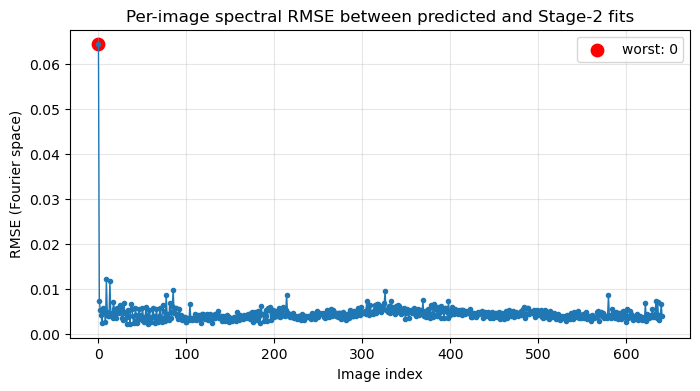

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# assume shapes (N,1089)
s_true = s_train
s_pred = np.load("train_predicted_s.npy")

rmse = np.sqrt(np.mean((s_pred - s_true)**2, axis=1))  # shape (N,)

plt.figure(figsize=(8,4))
plt.plot(rmse, marker='o', ms=3, lw=1)
plt.xlabel("Image index")
plt.ylabel("RMSE (Fourier space)")
plt.title("Per-image spectral RMSE between predicted and Stage-2 fits")
plt.grid(alpha=0.3)

# highlight the worst one
bad = np.argmax(rmse)
plt.scatter([bad], [rmse[bad]], color='red', s=80, label=f"worst: {bad}")
plt.legend()
plt.show()


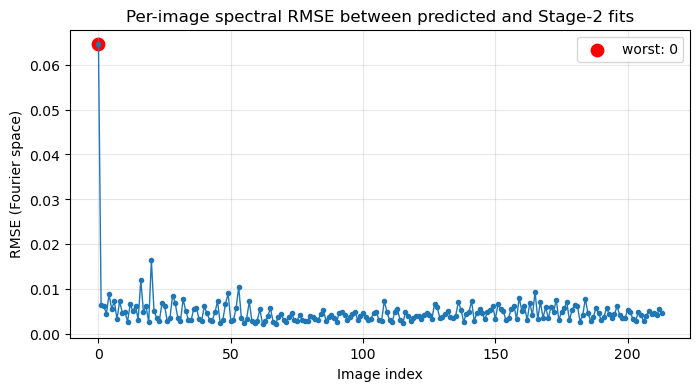

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# assume shapes (N,1089)
rmse = np.sqrt(np.mean((s_test - s_test_true)**2, axis=1))  # shape (N,)

plt.figure(figsize=(8,4))
plt.plot(rmse, marker='o', ms=3, lw=1)
plt.xlabel("Image index")
plt.ylabel("RMSE (Fourier space)")
plt.title("Per-image spectral RMSE between predicted and Stage-2 fits")
plt.grid(alpha=0.3)

# highlight the worst one
bad = np.argmax(rmse)
plt.scatter([bad], [rmse[bad]], color='red', s=80, label=f"worst: {bad}")
plt.legend()
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


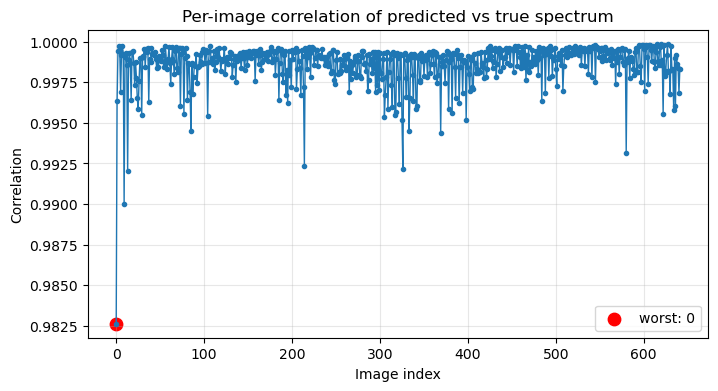

In [28]:
corr = []
for i in range(len(s_true)):
    corr.append(np.corrcoef(s_true[i], s_pred[i])[0,1])

corr = np.array(corr)

plt.figure(figsize=(8,4))
plt.plot(corr, marker='o', ms=3, lw=1)
plt.xlabel("Image index")
plt.ylabel("Correlation")
plt.title("Per-image correlation of predicted vs true spectrum")
plt.grid(alpha=0.3)

bad = np.argmin(corr)
plt.scatter([bad], [corr[bad]], color='red', s=80, label=f"worst: {bad}")
plt.legend()
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


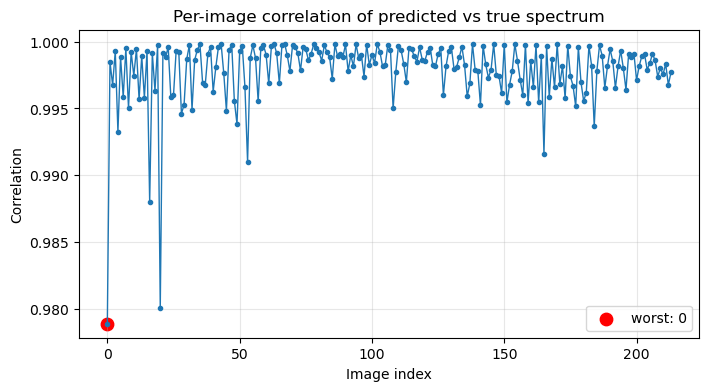

In [29]:
corr = []
for i in range(len(s_test_true)):
    corr.append(np.corrcoef(s_test_true[i], s_test[i])[0,1])

corr = np.array(corr)

plt.figure(figsize=(8,4))
plt.plot(corr, marker='o', ms=3, lw=1)
plt.xlabel("Image index")
plt.ylabel("Correlation")
plt.title("Per-image correlation of predicted vs true spectrum")
plt.grid(alpha=0.3)

bad = np.argmin(corr)
plt.scatter([bad], [corr[bad]], color='red', s=80, label=f"worst: {bad}")
plt.legend()
plt.show()


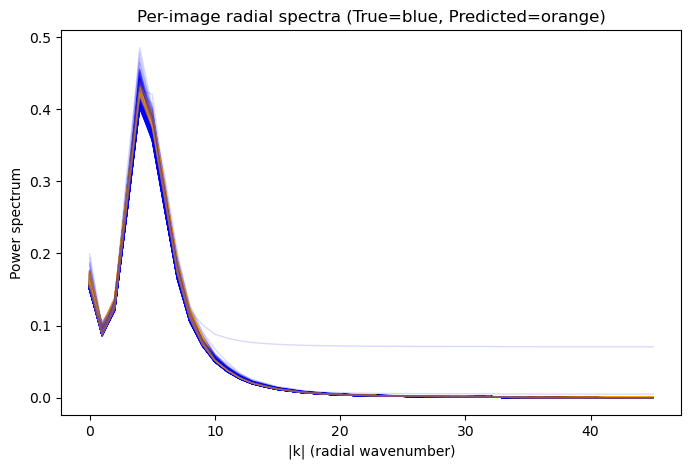

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# s_true, s_pred are (N,1089)

# --- build radial bins ---
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)     # 0..~45

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33,33)
    prof = []
    for r in range(R.max()+1):
        prof.append(grid[R == r].mean())
    return np.array(prof)

# --- compute all profiles ---
true_profiles = np.array([radial_profile(s_true[i]) for i in range(len(s_true))])
pred_profiles = np.array([radial_profile(s_pred[i]) for i in range(len(s_pred))])

# --- simple plot per image ---
plt.figure(figsize=(8,5))

for i in range(len(true_profiles)):
    plt.plot(true_profiles[i], color='blue', alpha=0.15, lw=1)
    plt.plot(pred_profiles[i], color='orange', alpha=0.15, lw=1)

# plt.yscale("log")
plt.xlabel("|k| (radial wavenumber)")
plt.ylabel("Power spectrum")
plt.title("Per-image radial spectra (True=blue, Predicted=orange)")
plt.show()


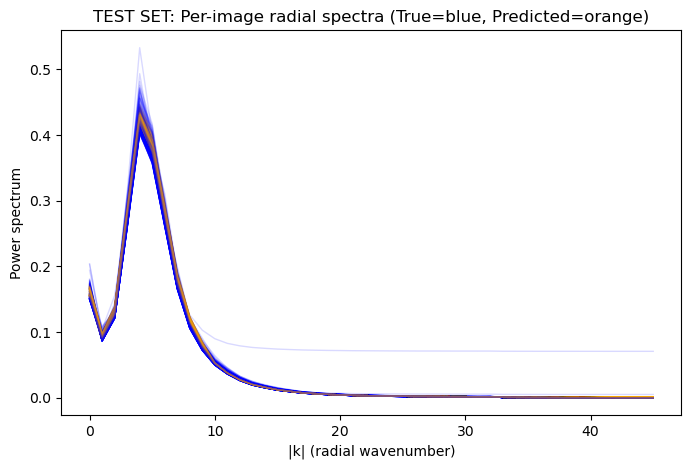

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# s_test_true, s_test are (N,1089)

# --- build radial bins ---
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)     # 0..~45

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33,33)
    prof = []
    for r in range(R.max()+1):
        prof.append(grid[R == r].mean())
    return np.array(prof)

# --- compute all profiles ---
true_profiles = np.array([radial_profile(s_test_true[i]) for i in range(len(s_test_true))])
pred_profiles = np.array([radial_profile(s_test[i]) for i in range(len(s_test))])

# --- simple plot per image ---
plt.figure(figsize=(8,5))

for i in range(len(true_profiles)):
    plt.plot(true_profiles[i], color='blue', alpha=0.15, lw=1)
    plt.plot(pred_profiles[i], color='orange', alpha=0.15, lw=1)

# plt.yscale("log")
plt.xlabel("|k| (radial wavenumber)")
plt.ylabel("Power spectrum")
plt.title("TEST SET: Per-image radial spectra (True=blue, Predicted=orange)")
plt.show()


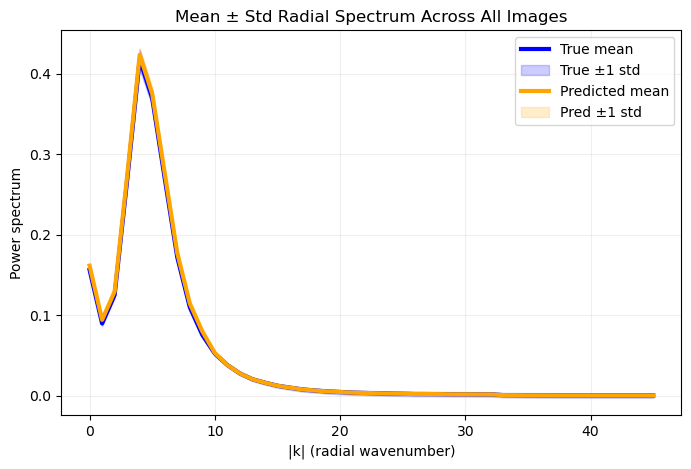

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- build radial bins ---
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33,33)
    vals = []
    for r in range(R.max()+1):
        vals.append(grid[R == r].mean())
    return np.array(vals)

# --- compute radial profiles for all images ---
true_profiles = np.array([radial_profile(s_true[i]) for i in range(len(s_true))])
pred_profiles = np.array([radial_profile(s_pred[i]) for i in range(len(s_pred))])

# --- compute mean and std ---
true_mean = true_profiles.mean(axis=0)
true_std  = true_profiles.std(axis=0)

pred_mean = pred_profiles.mean(axis=0)
pred_std  = pred_profiles.std(axis=0)

# --- make the plot ---
plt.figure(figsize=(8,5))

# True mean ± std
plt.plot(true_mean, color='blue', lw=3, label="True mean")
plt.fill_between(
    np.arange(len(true_mean)),
    true_mean - true_std,
    true_mean + true_std,
    color='blue',
    alpha=0.2,
    label="True ±1 std"
)

# Pred mean ± std
plt.plot(pred_mean, color='orange', lw=3, label="Predicted mean")
plt.fill_between(
    np.arange(len(pred_mean)),
    pred_mean - pred_std,
    pred_mean + pred_std,
    color='orange',
    alpha=0.2,
    label="Pred ±1 std"
)

# plt.yscale("log")
plt.xlabel("|k| (radial wavenumber)")
plt.ylabel("Power spectrum")
plt.title("Mean ± Std Radial Spectrum Across All Images")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


Hows the 2d fit accuracy

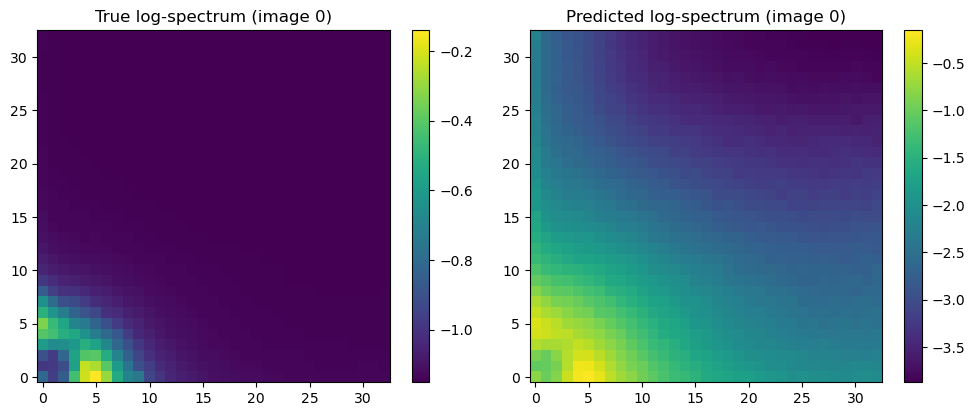

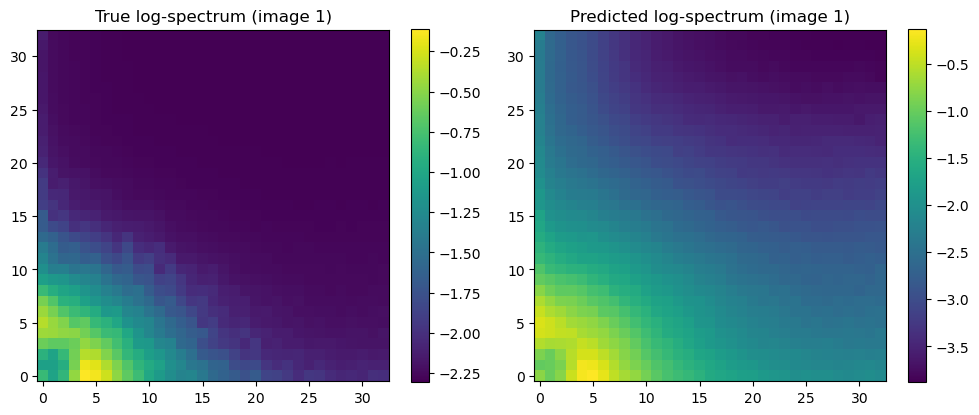

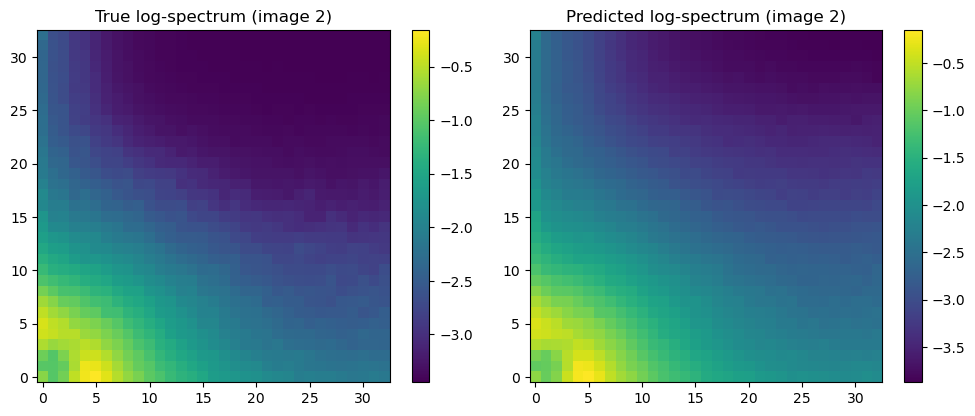

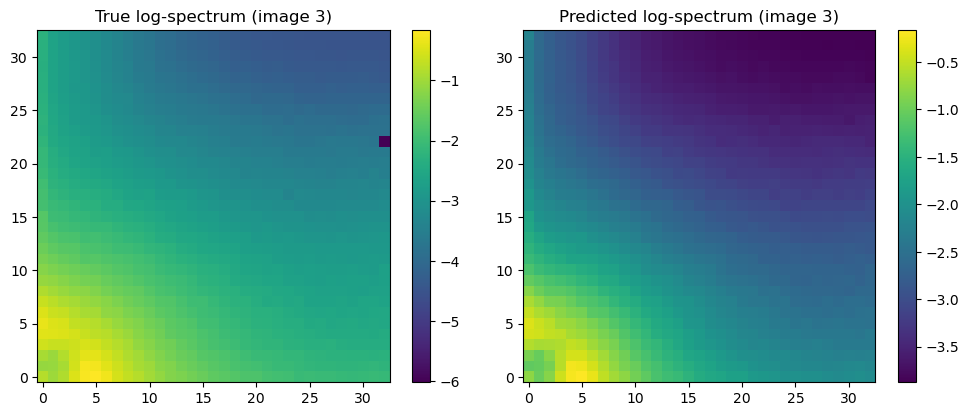

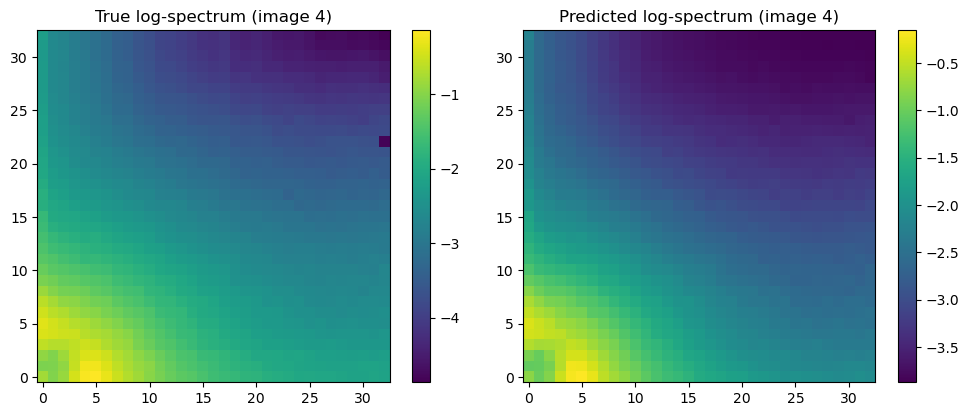

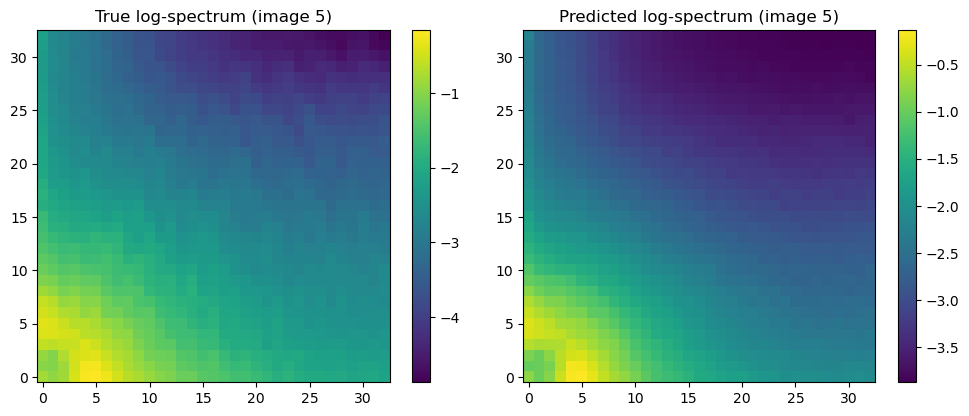

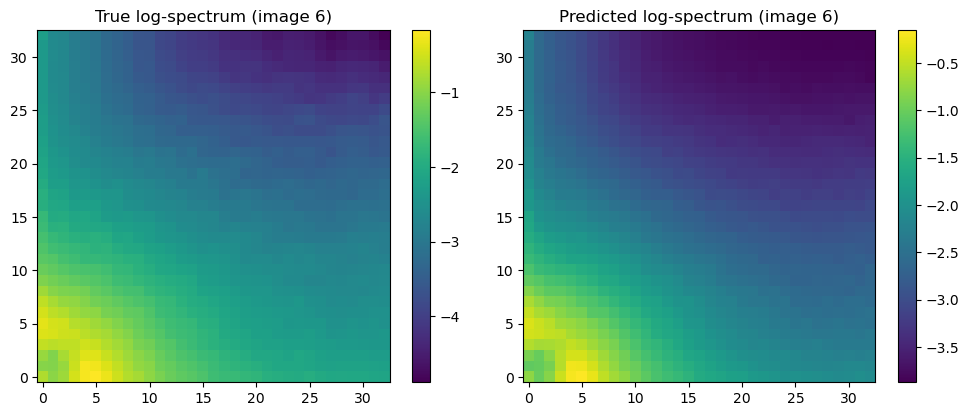

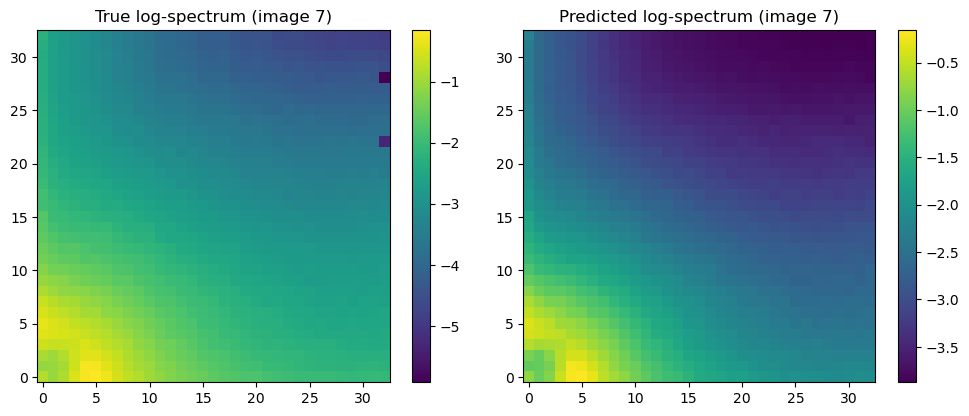

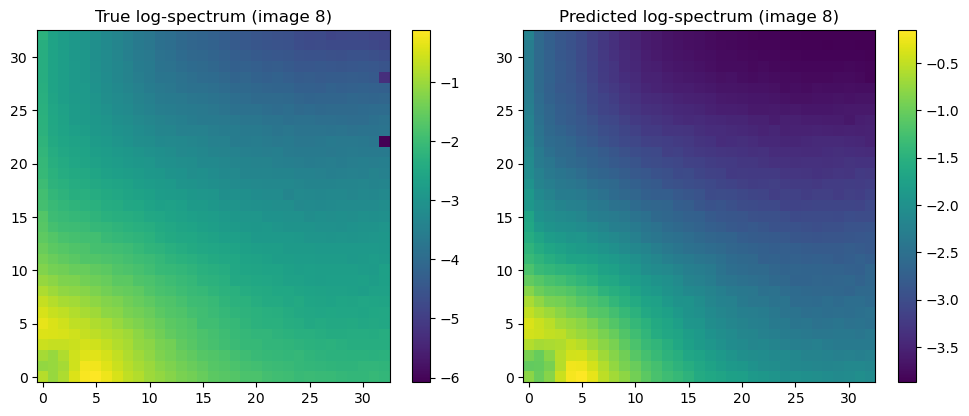

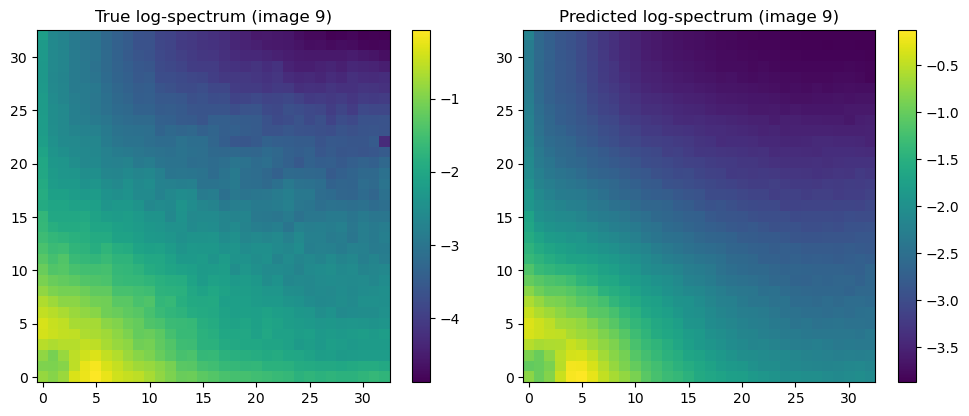

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def to_grid(v):
    return v.reshape(33,33)

for i in range(10): #    i = 2  # try different images

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(np.log10(to_grid(s_true[i]) + 1e-12), cmap='viridis', origin='lower')
    plt.title(f"True log-spectrum (image {i})")
    plt.colorbar()

    plt.subplot(1,2,2)
    plt.imshow(np.log10(to_grid(s_pred[i]) + 1e-12), cmap='viridis', origin='lower')
    plt.title(f"Predicted log-spectrum (image {i})")
    plt.colorbar()

    plt.tight_layout()
    plt.show()


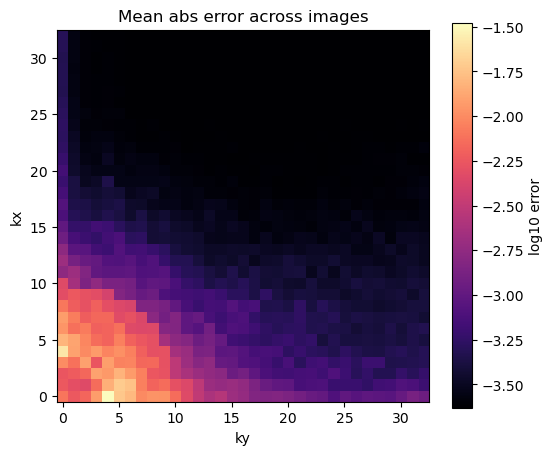

In [31]:
err_all = np.mean(np.abs(s_pred - s_true), axis=0).reshape(33,33)

plt.figure(figsize=(6,5))
plt.imshow(np.log10(err_all + 1e-12), cmap='magma', origin='lower')
plt.title("Mean abs error across images")
plt.colorbar(label="log10 error")
plt.xlabel("ky")
plt.ylabel("kx")
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/hgoldwyn/opt/anaconda3/envs/torch/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/hgoldwyn/opt/anaconda3/envs/torch/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


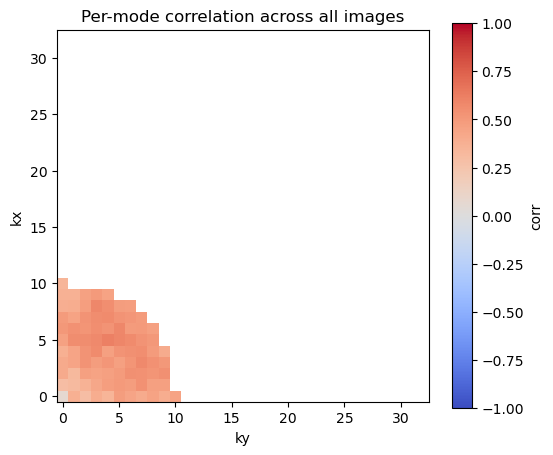

In [30]:
corr_map = np.zeros(1089)
for k in range(1089):
    corr_map[k] = np.corrcoef(s_true[:,k], s_pred[:,k])[0,1]

plt.figure(figsize=(6,5))
plt.imshow(corr_map.reshape(33,33), cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
plt.title("Per-mode correlation across all images")
plt.colorbar(label="corr")
plt.xlabel("ky")
plt.ylabel("kx")
plt.show()
